<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Stability004b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 100/100 [00:05<00:00, 16.92it/s]


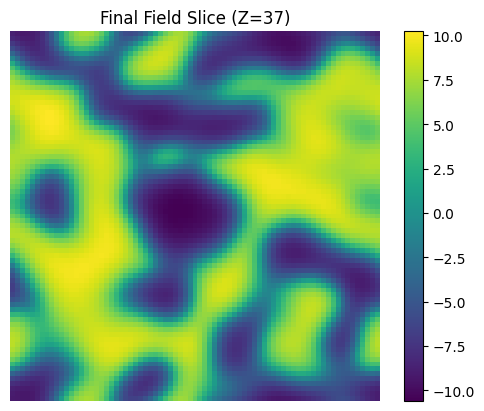

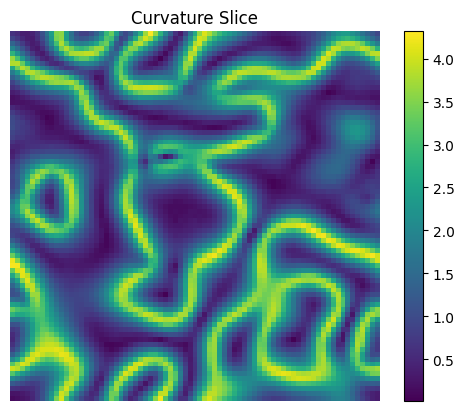

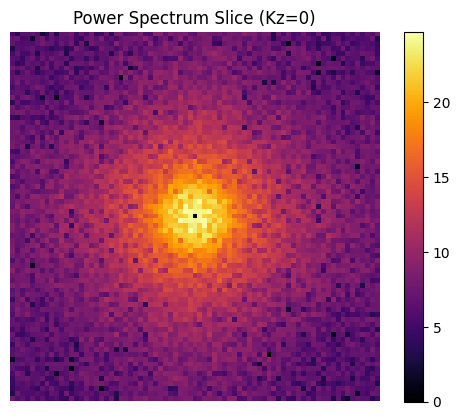

Stability004b (3D) → λ_dom ≈ 1.18


In [2]:
# Stability004b — Act XXXIII: The Dimensional Restoration
# 3D Attractor Test with Restored Parameters (alpha=0.1, gamma=0.2)

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftshift
from tqdm import tqdm

# --- Parameters ---
alpha, beta, gamma, delta = 0.1, 0.01, 0.2, 0.02
T_max = 100
L = 75
seed = 42

# --- Initialize 3D Field ---
np.random.seed(seed)
Phi = np.random.randn(L, L, L)

# --- 3D Laplacian Function ---
def laplacian_3d(Phi):
    return (
        np.roll(Phi, 1, axis=0) + np.roll(Phi, -1, axis=0) +
        np.roll(Phi, 1, axis=1) + np.roll(Phi, -1, axis=1) +
        np.roll(Phi, 1, axis=2) + np.roll(Phi, -1, axis=2) -
        6 * Phi
    )

# --- Simulation Loop ---
for t in tqdm(range(T_max)):
    lap = laplacian_3d(Phi)
    noise = delta * np.random.randn(L, L, L)
    Phi += alpha * lap - beta * Phi + gamma * np.tanh(Phi) + noise

# --- 3D Fourier Analysis ---
spectrum = np.abs(fftshift(fftn(Phi)))**2
center = np.array(spectrum.shape) // 2
spectrum[tuple(center)] = 0  # Remove DC component

# Find peak in spectrum
peak_idx = np.unravel_index(np.argmax(spectrum), spectrum.shape)
k_coords = np.fft.fftfreq(L)
k_x, k_y, k_z = k_coords[peak_idx[0]], k_coords[peak_idx[1]], k_coords[peak_idx[2]]
k_dom = np.sqrt(k_x**2 + k_y**2 + k_z**2)
lambda_dom = 1 / k_dom if k_dom != 0 else np.inf

# --- Visualization ---
def show_slice(field, title, cmap='viridis'):
    if field.ndim == 3:
        slice_2d = field[:, :, L//2]
    elif field.ndim == 2:
        slice_2d = field
    else:
        raise ValueError("Unsupported field dimensionality")
    plt.imshow(slice_2d, cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.axis('off')
    plt.show()

# Visualize slices
show_slice(Phi, f'Final Field Slice (Z={L//2})')
curvature = np.sqrt(np.sum(np.array(np.gradient(Phi))**2, axis=0))
show_slice(curvature, 'Curvature Slice')
show_slice(np.log1p(spectrum[:, :, center[2]]), 'Power Spectrum Slice (Kz=0)', cmap='inferno')

# --- Output ---
print(f"Stability004b (3D) → λ_dom ≈ {lambda_dom:.2f}")
